In [1]:
#Customer Retention & Churn Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
#LOADING DATASET
df=pd.read_csv("Sample-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
#DATA CLEANING
#checking missing values
print(df.isnull().sum())

#convert TotalCharges to numeric
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

#drop missing values
df.dropna(inplace=True)

#convert Yes/No to 1/0
df['Churn']=df['Churn'].map({'Yes':1,'No':0})

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [10]:
#Basic information
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,0.265785
std,0.368844,24.545260,30.085974,2266.771362,0.441782
min,0.000000,1.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.587500,401.450000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.862500,3794.737500,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


In [11]:
#Churn rate
churn_rate=df['Churn'].mean()*100
print("Churn Rate:",churn_rate)

Churn Rate: 26.578498293515356


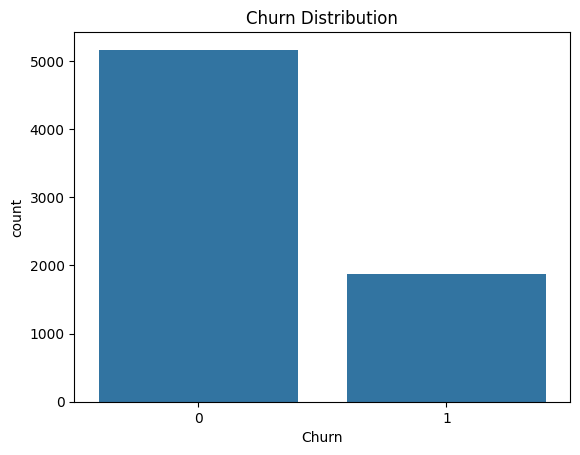

In [12]:
#churn distribution
sns.countplot(x='Churn',data=df)
plt.title("Churn Distribution")
plt.show()

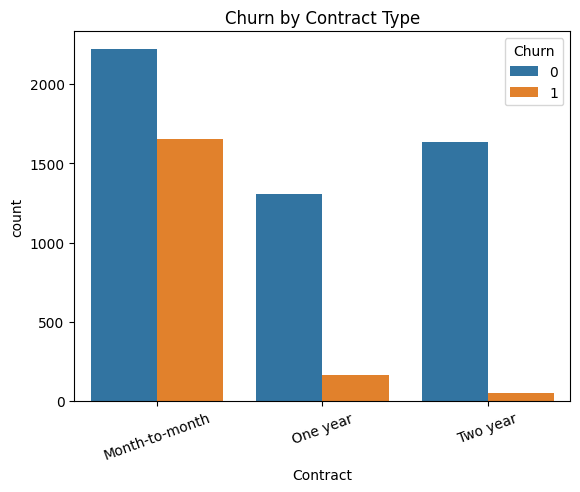

In [13]:
#Churn by Contract type
sns.countplot(x='Contract',hue='Churn',data=df)
plt.title("Churn by Contract Type")
plt.xticks(rotation=20)
plt.show()

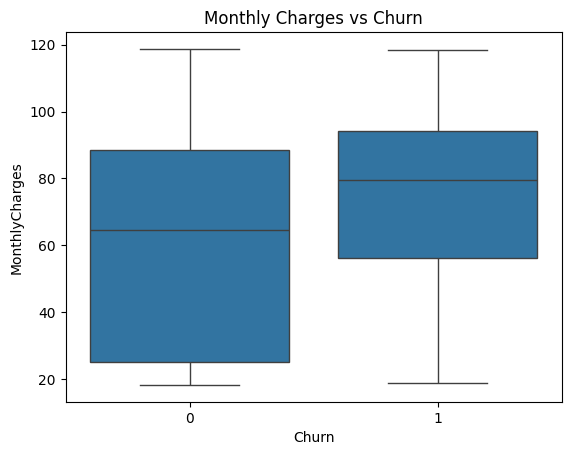

In [14]:
#Monthly Charges vs Churn
sns.boxplot(x='Churn',y='MonthlyCharges',data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

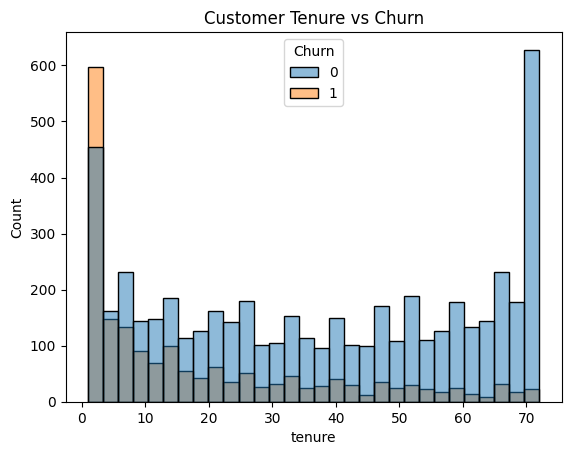

In [17]:
#Tenure(Customer lifetime)
sns.histplot(data=df,x='tenure',hue='Churn',bins=30)
plt.title("Customer Tenure vs Churn")
plt.show()

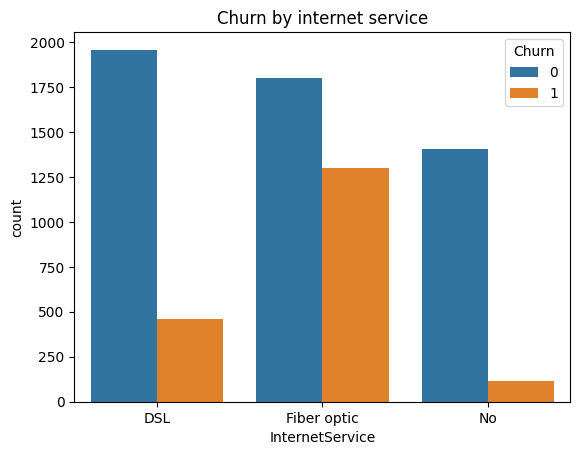

In [19]:
#Churn by internet service
sns.countplot(x='InternetService',hue='Churn',data=df)
plt.title("Churn by internet service")
plt.show()

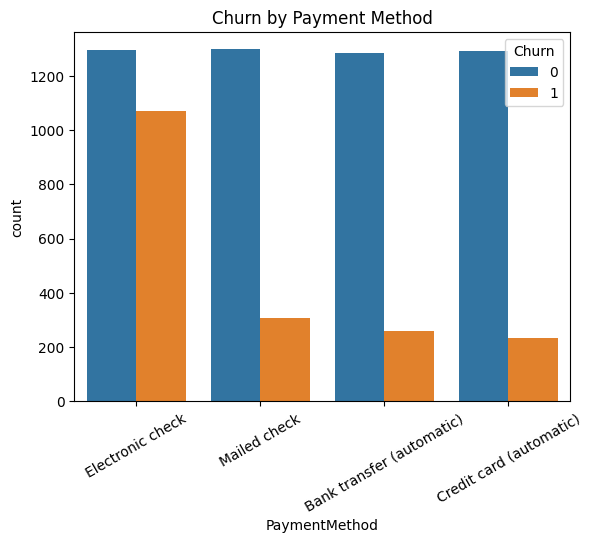

In [22]:
#Churn by payment method
sns.countplot(x='PaymentMethod',hue='Churn',data=df)
plt.title("Churn by Payment Method")
plt.xticks(rotation=30)
plt.show()

In [24]:
#cohort analysis(Tenure Groups)
df['tenure_group']=pd.cut(df['tenure'],bins=[0,12,24,48,60,72])
cohort=df.groupby('tenure_group')['Churn'].mean()
print(cohort)

tenure_group
(0, 12]     0.476782
(12, 24]    0.287109
(24, 48]    0.203890
(48, 60]    0.144231
(60, 72]    0.066098
Name: Churn, dtype: float64


/tmp/ipykernel_4418/2585505499.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cohort=df.groupby('tenure_group')['Churn'].mean()


In [25]:
#customer lifetime value
avg_monthly_charge=df['MonthlyCharges'].mean()
avg_lifetime=df['tenure'].mean()
clv=avg_monthly_charge*avg_lifetime
print("Average monthly charge:",avg_monthly_charge)
print("Average lifetime:",avg_lifetime)
print("Customer Lifetime Value:",clv)

Average monthly charge: 64.79820819112628
Average lifetime: 32.421786120591584
Customer Lifetime Value: 2100.8736469702617


In [26]:
#High churn segments
high_churn=df[df['Churn']==1]
print(high_churn.describe())

       SeniorCitizen       tenure  MonthlyCharges  TotalCharges   Churn
count    1869.000000  1869.000000     1869.000000   1869.000000  1869.0
mean        0.254682    17.979133       74.441332   1531.796094     1.0
std         0.435799    19.531123       24.666053   1890.822994     0.0
min         0.000000     1.000000       18.850000     18.850000     1.0
25%         0.000000     2.000000       56.150000    134.500000     1.0
50%         0.000000    10.000000       79.650000    703.550000     1.0
75%         1.000000    29.000000       94.200000   2331.300000     1.0
max         1.000000    72.000000      118.350000   8684.800000     1.0


In [27]:
#saving clean data
df.to_csv("Cleaned_churn_data.csv",index=False)

In [28]:
# KEY INSIGHTS:
# -Customers with month-to-month contracts have highest churn
# -High monthly charges increase churn possibility
# -Customers with low tenure (0-12 months) churn more
# -Certain payment methods show higher churn rates
# -Customers without value-added services(like tech support) tend to churn more

In [29]:
# RECOMMENDATIONS
# -Offer discounts for long-term contracts
# -Improve onboarding for new users
# -Provide better customer support services
# -Target high-risk customers with retention offers